# Cat vs Dog Image Classifier
### Optimized for 8GB RAM | CNN + MobileNetV2 | TensorFlow & Keras
---
**Dataset:** Local — `dogs-vs-cats/cat/` + `dogs-vs-cats/dogs/`  
**IMG_SIZE:** 128×128 (optimized for 8GB RAM)  
**Split:** 70% Train | 15% Val | 15% Test  
---

## Step 1 — Memory Management (Run This First!)

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress TF logs

import tensorflow as tf

# Prevent TensorFlow from grabbing all RAM at once
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU found: {gpus}')
else:
    print('No GPU — using CPU')

# Limit CPU threads to reduce RAM pressure
tf.config.threading.set_inter_op_parallelism_threads(2)
tf.config.threading.set_intra_op_parallelism_threads(2)

print(f'TensorFlow : {tf.__version__}')
print('Memory settings applied!')

No GPU — using CPU
TensorFlow : 2.21.0
Memory settings applied!


## Step 1 — Import Libraries

In [2]:
import shutil, random, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.utils import image_dataset_from_directory
from PIL import Image
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print('All libraries imported!')

All libraries imported!


## ⚙️ Step 3 — Configuration (Optimized for 8GB RAM)

In [3]:
# ── PATH ─────────────────────────────────────────────────────
DATASET_DIR = 'dogs-vs-cats'
# If notebook is in different location use full path:
# DATASET_DIR = r'C:\Users\Zain Abbas\Desktop\dogs-vs-cats'

# ── IMAGE SETTINGS (Safe for 8GB RAM) ────────────────────────
IMG_SIZE   = 128   # DO NOT increase — will crash on 8GB
BATCH_SIZE = 16    # DO NOT increase — will crash on 8GB
SPLIT_DIR  = 'dataset_split'
AUTOTUNE   = tf.data.AUTOTUNE
SEED       = 42

print(f'IMG_SIZE   : {IMG_SIZE}x{IMG_SIZE}')
print(f'BATCH_SIZE : {BATCH_SIZE}')
print(f'Dataset    : {DATASET_DIR}')

IMG_SIZE   : 128x128
BATCH_SIZE : 16
Dataset    : dogs-vs-cats


## Step 2 — Verify Dataset

In [4]:
# Auto-detect folder names (handles 'dog' or 'dogs', 'cat' or 'cats')
subfolders = os.listdir(DATASET_DIR)
print(f'Folders found inside {DATASET_DIR}: {subfolders}')

CAT_DIR = None
DOG_DIR = None
for folder in subfolders:
    if folder.lower() in ['cat', 'cats']:
        CAT_DIR = os.path.join(DATASET_DIR, folder)
    if folder.lower() in ['dog', 'dogs']:
        DOG_DIR = os.path.join(DATASET_DIR, folder)

assert CAT_DIR is not None, f'Cat folder not found! Found: {subfolders}'
assert DOG_DIR is not None, f'Dog folder not found! Found: {subfolders}'

cat_images = [f for f in os.listdir(CAT_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]
dog_images = [f for f in os.listdir(DOG_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))]

print(f'Cat folder : {CAT_DIR} — {len(cat_images):,} images')
print(f'Dog folder : {DOG_DIR} — {len(dog_images):,} images')
print(f'Total      : {len(cat_images)+len(dog_images):,} images')
print('Dataset verified!')

Folders found inside dogs-vs-cats: ['cat', 'dog']
Cat folder : dogs-vs-cats\cat — 5,000 images
Dog folder : dogs-vs-cats\dog — 5,000 images
Total      : 10,000 images
Dataset verified!


## Step 3 — Split Dataset (70/15/15)

In [5]:
def split_and_organize(src_dir, class_name, split_dir,
                        train_r=0.70, val_r=0.15, seed=42):
    images = [f for f in os.listdir(src_dir)
               if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.seed(seed)
    random.shuffle(images)
    n       = len(images)
    n_train = int(n * train_r)
    n_val   = int(n * val_r)
    splits  = {
        'train': images[:n_train],
        'val'  : images[n_train:n_train+n_val],
        'test' : images[n_train+n_val:]
    }
    for split_name, files in splits.items():
        dest = os.path.join(split_dir, split_name, class_name)
        os.makedirs(dest, exist_ok=True)
        for fname in files:
            shutil.copy2(os.path.join(src_dir, fname),
                         os.path.join(dest, fname))
    return {k: len(v) for k, v in splits.items()}

if not os.path.exists(SPLIT_DIR):
    print('Splitting dataset...')
    cat_c = split_and_organize(CAT_DIR, 'cat', SPLIT_DIR)
    dog_c = split_and_organize(DOG_DIR, 'dog', SPLIT_DIR)
    print(f'Train : {cat_c["train"]+dog_c["train"]:,} images')
    print(f'Val   : {cat_c["val"]+dog_c["val"]:,} images')
    print(f'Test  : {cat_c["test"]+dog_c["test"]:,} images')
else:
    print('Split folder already exists — skipping.')
    for split in ['train','val','test']:
        total = sum(len(os.listdir(os.path.join(SPLIT_DIR,split,c)))
                    for c in os.listdir(os.path.join(SPLIT_DIR,split)))
        print(f'{split:6s}: {total:,} images')

Split folder already exists — skipping.
train : 7,000 images
val   : 1,500 images
test  : 1,500 images


## Step 4 — EDA

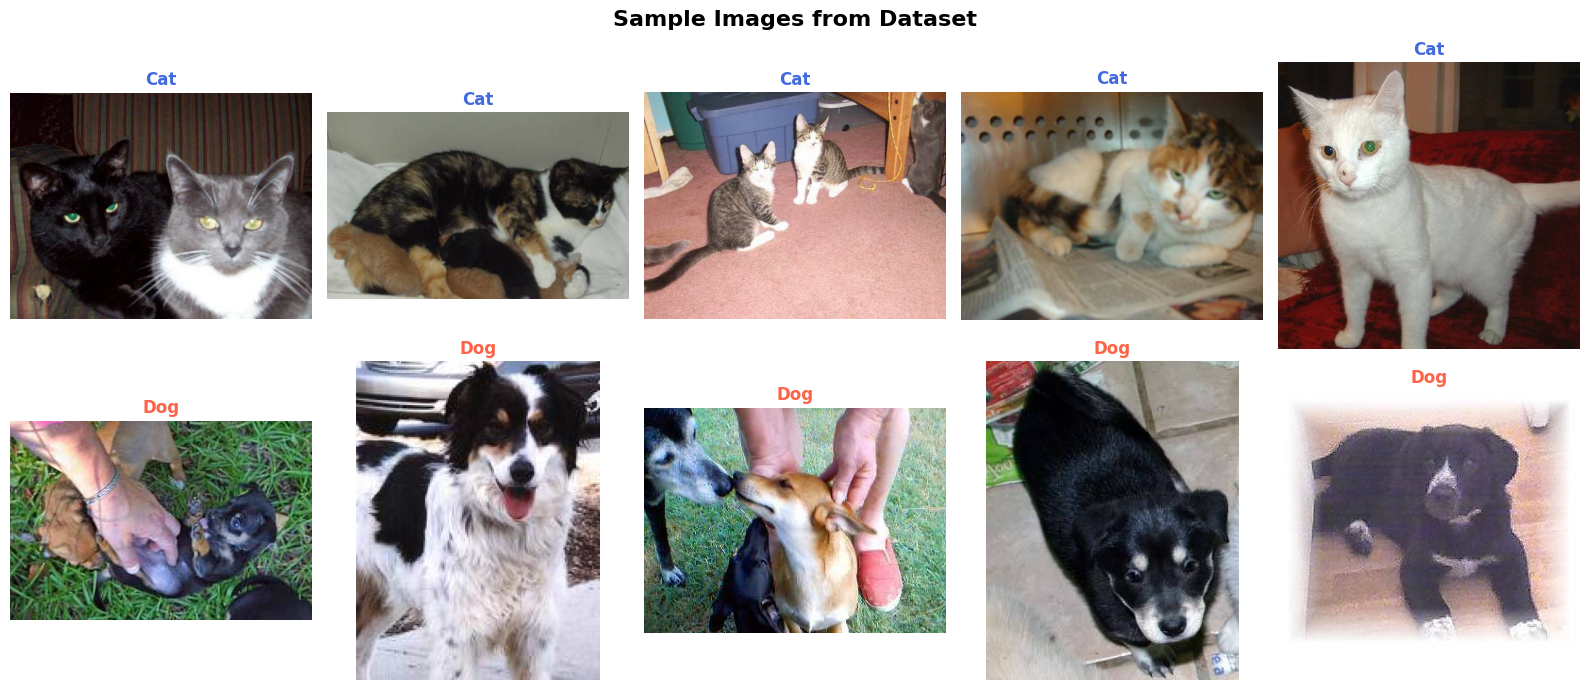

Saved: sample_images.png


In [6]:
CLASS_NAMES = ['cat', 'dog']

# Sample images
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold')
for row, (folder, label, color) in enumerate([
    (CAT_DIR, 'Cat', 'royalblue'),
    (DOG_DIR, 'Dog', 'tomato')
]):
    files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    samples = random.sample(files, 5)
    for col, fname in enumerate(samples):
        img = plt.imread(os.path.join(folder, fname))
        axes[row][col].imshow(img)
        axes[row][col].set_title(label, color=color, fontweight='bold')
        axes[row][col].axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

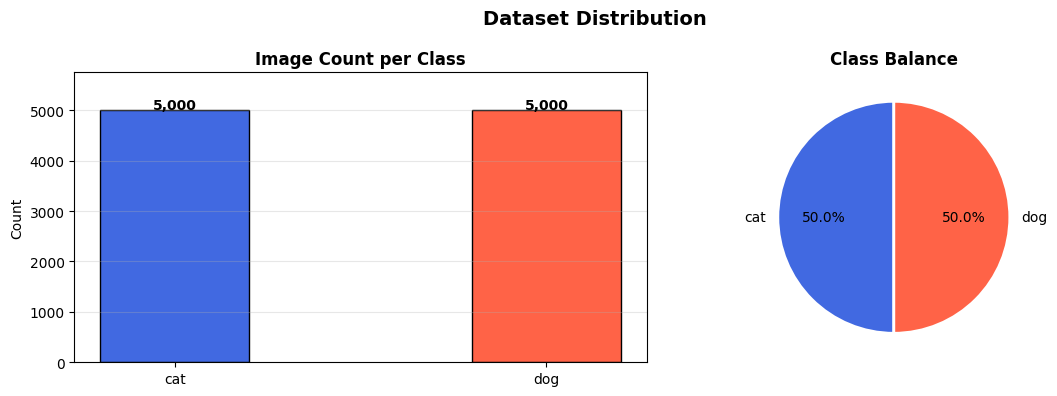

Saved: class_distribution.png


In [7]:
# Class distribution chart
counts = [len(cat_images), len(dog_images)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset Distribution', fontsize=14, fontweight='bold')
bars = axes[0].bar(CLASS_NAMES, counts,
                   color=['royalblue','tomato'], edgecolor='black', width=0.4)
axes[0].set_title('Image Count per Class', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+30, f'{count:,}',
                 ha='center', fontweight='bold')
axes[0].set_ylim(0, max(counts)*1.15)
axes[0].grid(axis='y', alpha=0.3)
axes[1].pie(counts, labels=CLASS_NAMES, autopct='%1.1f%%',
            colors=['royalblue','tomato'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Class Balance', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: class_distribution.png')

## Step 5 — Data Pipelines & Augmentation

In [8]:
# Augmentation layer
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='augmentation')

# Load datasets
train_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'train'),
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    label_mode='binary', shuffle=True, seed=SEED)

val_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'val'),
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    label_mode='binary', shuffle=False, seed=SEED)

test_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, 'test'),
    image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    label_mode='binary', shuffle=False, seed=SEED)

CLASS_NAMES = train_ds.class_names
print(f'Classes      : {CLASS_NAMES}')
print(f'Train batches: {len(train_ds)}')
print(f'Val batches  : {len(val_ds)}')
print(f'Test batches : {len(test_ds)}')

# Normalize to [0,1]
normalize = layers.Rescaling(1./255)
train_ds = (train_ds
    .map(lambda x,y: (normalize(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(200)
    .prefetch(AUTOTUNE))
val_ds  = (val_ds
    .map(lambda x,y: (normalize(x), y), num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE))
test_ds = (test_ds
    .map(lambda x,y: (normalize(x), y), num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE))

print('Pipelines ready!')

Found 7000 files belonging to 2 classes.
Found 1500 files belonging to 2 classes.
Found 1500 files belonging to 2 classes.
Classes      : ['cat', 'dog']
Train batches: 438
Val batches  : 94
Test batches : 94
Pipelines ready!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.08727592..1.0135853].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.1371029..1.001863].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.101041496..1.011849].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.12966448..1.0045023].


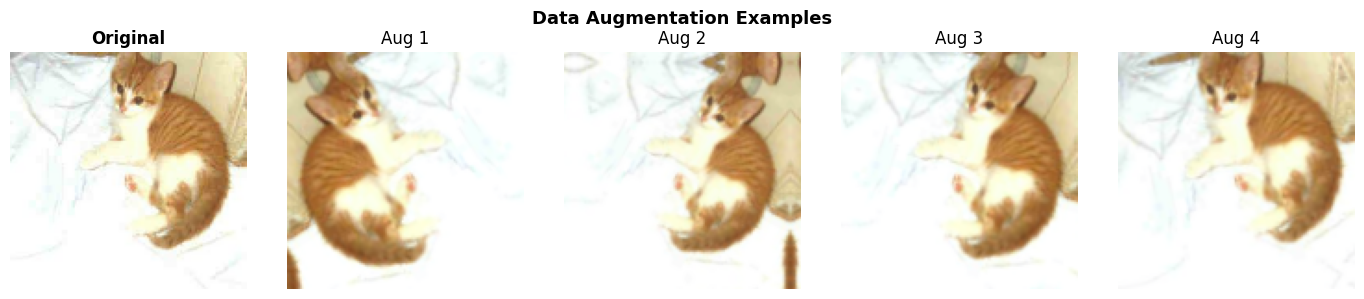

Saved: augmentation_examples.png


In [9]:
# Visualize augmentation
sample_img, _ = next(iter(train_ds.take(1)))
sample_img = sample_img[:1]
plt.figure(figsize=(14, 3))
plt.suptitle('Data Augmentation Examples', fontsize=13, fontweight='bold')
plt.subplot(1,5,1)
plt.imshow(tf.squeeze(sample_img))
plt.title('Original', fontweight='bold'); plt.axis('off')
for i in range(4):
    aug = data_augmentation(sample_img, training=True)
    plt.subplot(1,5,i+2)
    plt.imshow(tf.squeeze(aug))
    plt.title(f'Aug {i+1}'); plt.axis('off')
plt.tight_layout()
plt.savefig('augmentation_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: augmentation_examples.png')

## Step 6 — Model 1: Custom CNN
> Train this first. Then clear memory before running MobileNetV2.

In [10]:
def build_custom_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    # Block 1
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    # Block 2
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    # Block 3
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)
    # Head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs, outputs, name='CustomCNN')

cnn_model = build_custom_cnn()
cnn_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
cnn_model.summary()

Model: "CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [11]:
cnn_callbacks = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5,
                             restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint('best_cnn.keras', monitor='val_accuracy',
                               save_best_only=True, verbose=1)
]

print('Training Custom CNN...')
cnn_history = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=cnn_callbacks
)
print(f'Best Val Accuracy: {max(cnn_history.history["val_accuracy"])*100:.2f}%')

Training Custom CNN...
Epoch 1/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.5588 - auc: 0.5780 - loss: 0.7260
Epoch 1: val_accuracy improved from None to 0.56067, saving model to best_cnn.keras

Epoch 1: finished saving model to best_cnn.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 213s 475ms/step - accuracy: 0.5780 - auc: 0.6074 - loss: 0.6901 - val_accuracy: 0.5607 - val_auc: 0.6586 - val_loss: 0.7103 - learning_rate: 0.0010
Epoch 2/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.6004 - auc: 0.6405 - loss: 0.6628
Epoch 2: val_accuracy did not improve from 0.56067
438/438 ━━━━━━━━━━━━━━━━━━━━ 225s 513ms/step - accuracy: 0.6059 - auc: 0.6476 - loss: 0.6594 - val_accuracy: 0.5600 - val_auc: 0.6664 - val_loss: 0.7216 - learning_rate: 0.0010
Epoch 3/20
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.6092 - auc: 0.6635 - loss: 0.6508
Epoch 3: val_accuracy improved from 0.56067 to 0.67533, saving model to best_cnn.keras

Epoch 3: finished saving model to best_cnn.k

## Step 7 — Evaluate Custom CNN

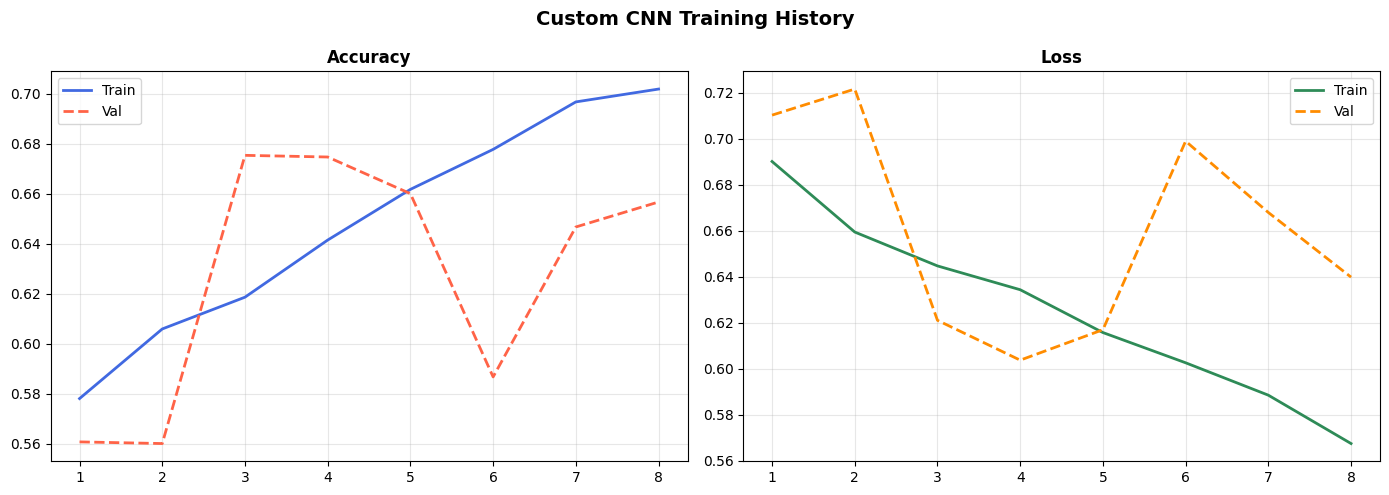

Saved: cnn_training_history.png


In [12]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Custom CNN Training History', fontsize=14, fontweight='bold')
ep = range(1, len(cnn_history.history['accuracy'])+1)
axes[0].plot(ep, cnn_history.history['accuracy'],     color='royalblue', lw=2, label='Train')
axes[0].plot(ep, cnn_history.history['val_accuracy'], color='tomato',    lw=2, linestyle='--', label='Val')
axes[0].set_title('Accuracy', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, cnn_history.history['loss'],         color='seagreen',    lw=2, label='Train')
axes[1].plot(ep, cnn_history.history['val_loss'],     color='darkorange',  lw=2, linestyle='--', label='Val')
axes[1].set_title('Loss', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_training_history.png')

CNN Test Accuracy: 65.53%
              precision    recall  f1-score   support

         cat       0.64      0.72      0.68       750
         dog       0.68      0.59      0.63       750

    accuracy                           0.66      1500
   macro avg       0.66      0.66      0.65      1500
weighted avg       0.66      0.66      0.65      1500



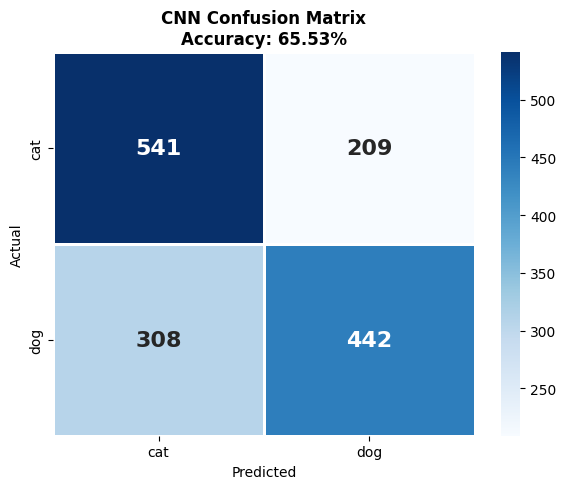

Saved: cnn_confusion_matrix.png


In [13]:
# CNN predictions & confusion matrix
cnn_proba = cnn_model.predict(test_ds, verbose=0).flatten()
cnn_pred  = (cnn_proba > 0.5).astype(int)
cnn_true  = np.concatenate([y.numpy() for _,y in test_ds]).astype(int)

print(f'CNN Test Accuracy: {accuracy_score(cnn_true, cnn_pred)*100:.2f}%')
print(classification_report(cnn_true, cnn_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(cnn_true, cnn_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'size':16,'weight':'bold'})
plt.title(f'CNN Confusion Matrix\nAccuracy: {accuracy_score(cnn_true,cnn_pred)*100:.2f}%',
          fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_confusion_matrix.png')

In [14]:
# Save CNN results before clearing memory
cnn_acc  = accuracy_score(cnn_true, cnn_pred)
fpr, tpr, _ = roc_curve(cnn_true, cnn_proba)
cnn_auc  = auc(fpr, tpr)
cnn_fpr, cnn_tpr = fpr, tpr
print(f'CNN  — Accuracy: {cnn_acc*100:.2f}%  AUC: {cnn_auc:.4f}')

# CLEAR MEMORY before loading MobileNetV2
del cnn_model
gc.collect()
tf.keras.backend.clear_session()
print('Memory cleared! Ready for MobileNetV2.')

CNN  — Accuracy: 65.53%  AUC: 0.7263

Memory cleared! Ready for MobileNetV2.


## Step 8 — Model 2: MobileNetV2 (Transfer Learning)
> Memory has been cleared. Now safe to load MobileNetV2.

In [15]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Rebuild pipelines with MobileNetV2 preprocessing
def load_ds_mobilenet(split_name):
    ds = image_dataset_from_directory(
        os.path.join(SPLIT_DIR, split_name),
        image_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE,
        label_mode='binary',
        shuffle=(split_name == 'train'),
        seed=SEED)
    return (ds
        .map(lambda x,y: (preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
        .cache()
        .prefetch(AUTOTUNE))

train_ds_mn = load_ds_mobilenet('train')
val_ds_mn   = load_ds_mobilenet('val')
test_ds_mn  = load_ds_mobilenet('test')
print('MobileNetV2 pipelines ready!')

Found 7000 files belonging to 2 classes.
Found 1500 files belonging to 2 classes.
Found 1500 files belonging to 2 classes.
MobileNetV2 pipelines ready!


In [19]:
# Load pretrained weights from local file
# Make sure you downloaded the weights file and placed it here:
WEIGHTS_PATH = r'C:\Users\Zain Abbas\.keras\models\mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_128_no_top.h5'

# Check if local weights exist, else try downloading
if os.path.exists(WEIGHTS_PATH):
    print(f'Loading weights from local file...')
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights=WEIGHTS_PATH
    )
else:
    print('Local weights not found — trying download...')
    print('If this fails, download manually from your browser:')
    print('https://storage.googleapis.com/tensorflow/keras-applications/mobilenet_v2/mobilenet_v2_weights_tf_dim_ordering_tf_kernels_1.0_128_no_top.h5')
    print(f'Save to: C:\\Users\\Zain Abbas\\.keras\\models\\')
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

base_model.trainable = False

# Rebuild augmentation after session clear
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
], name='augmentation')

inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = data_augmentation(inputs)
x       = base_model(x, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
tl_model = keras.Model(inputs, outputs, name='MobileNetV2_Transfer')

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
print('MobileNetV2 model built!')

Loading weights from local file...
MobileNetV2 model built!


In [20]:
# Phase 1 — Train head only
print('Phase 1: Training head...')
tl_history_1 = tl_model.fit(
    train_ds_mn, validation_data=val_ds_mn, epochs=5,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_accuracy', patience=3,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=2, verbose=1)
    ]
)
print(f'Phase 1 done — Val Acc: {max(tl_history_1.history["val_accuracy"])*100:.2f}%')

Phase 1: Training head...
Epoch 1/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 129s 281ms/step - accuracy: 0.9093 - auc: 0.9702 - loss: 0.2269 - val_accuracy: 0.9773 - val_auc: 0.9975 - val_loss: 0.0672 - learning_rate: 0.0010
Epoch 2/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 72s 165ms/step - accuracy: 0.9274 - auc: 0.9803 - loss: 0.1793 - val_accuracy: 0.9793 - val_auc: 0.9973 - val_loss: 0.0670 - learning_rate: 0.0010
Epoch 3/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 74s 168ms/step - accuracy: 0.9397 - auc: 0.9844 - loss: 0.1569 - val_accuracy: 0.9787 - val_auc: 0.9978 - val_loss: 0.0605 - learning_rate: 0.0010
Epoch 4/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 66s 151ms/step - accuracy: 0.9319 - auc: 0.9831 - loss: 0.1642 - val_accuracy: 0.9793 - val_auc: 0.9976 - val_loss: 0.0628 - learning_rate: 0.0010
Epoch 5/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.9419 - auc: 0.9846 - loss: 0.1548
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
438/438 ━━━━━━━━━━━━━━━━━━━━ 89s 203ms/step - accura

In [21]:
# Phase 2 — Fine-tune last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
print('Phase 2: Fine-tuning last 30 layers with lr=1e-5...')
tl_history_2 = tl_model.fit(
    train_ds_mn, validation_data=val_ds_mn, epochs=15,
    callbacks=[
        callbacks.EarlyStopping(monitor='val_accuracy', patience=4,
                                restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=2, verbose=1),
        callbacks.ModelCheckpoint('best_mobilenet.keras',
                                   monitor='val_accuracy',
                                   save_best_only=True, verbose=1)
    ]
)
print(f'Fine-tuning done — Val Acc: {max(tl_history_2.history["val_accuracy"])*100:.2f}%')

Phase 2: Fine-tuning last 30 layers with lr=1e-5...
Epoch 1/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9003 - auc: 0.9676 - loss: 0.2372
Epoch 1: val_accuracy improved from None to 0.97133, saving model to best_mobilenet.keras

Epoch 1: finished saving model to best_mobilenet.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 139s 291ms/step - accuracy: 0.9049 - auc: 0.9704 - loss: 0.2231 - val_accuracy: 0.9713 - val_auc: 0.9962 - val_loss: 0.0778 - learning_rate: 1.0000e-05
Epoch 2/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.9262 - auc: 0.9778 - loss: 0.1922
Epoch 2: val_accuracy improved from 0.97133 to 0.97333, saving model to best_mobilenet.keras

Epoch 2: finished saving model to best_mobilenet.keras
438/438 ━━━━━━━━━━━━━━━━━━━━ 107s 245ms/step - accuracy: 0.9253 - auc: 0.9769 - loss: 0.1939 - val_accuracy: 0.9733 - val_auc: 0.9969 - val_loss: 0.0717 - learning_rate: 1.0000e-05
Epoch 3/15
438/438 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9204 - auc: 0.9769 

## Step 9 — Evaluate MobileNetV2 + Final Comparison

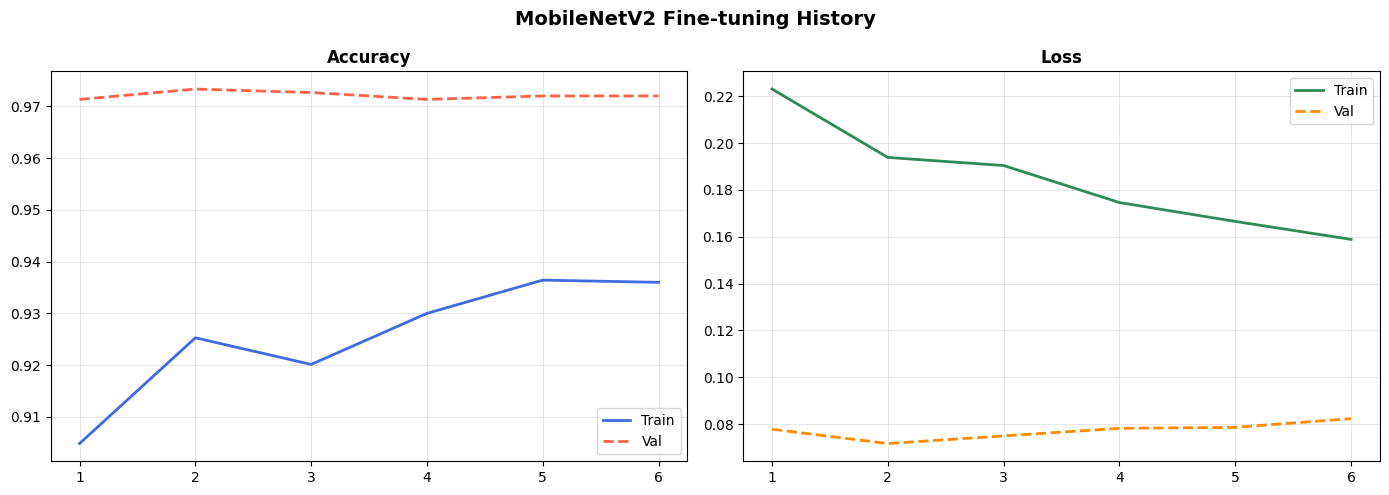

Saved: mobilenet_training_history.png


In [22]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MobileNetV2 Fine-tuning History', fontsize=14, fontweight='bold')
ep = range(1, len(tl_history_2.history['accuracy'])+1)
axes[0].plot(ep, tl_history_2.history['accuracy'],     color='royalblue', lw=2, label='Train')
axes[0].plot(ep, tl_history_2.history['val_accuracy'], color='tomato',    lw=2, linestyle='--', label='Val')
axes[0].set_title('Accuracy', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(ep, tl_history_2.history['loss'],         color='seagreen',   lw=2, label='Train')
axes[1].plot(ep, tl_history_2.history['val_loss'],     color='darkorange', lw=2, linestyle='--', label='Val')
axes[1].set_title('Loss', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mobilenet_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mobilenet_training_history.png')

MobileNetV2 Test Accuracy: 98.60%
              precision    recall  f1-score   support

         cat       0.98      0.99      0.99       750
         dog       0.99      0.98      0.99       750

    accuracy                           0.99      1500
   macro avg       0.99      0.99      0.99      1500
weighted avg       0.99      0.99      0.99      1500



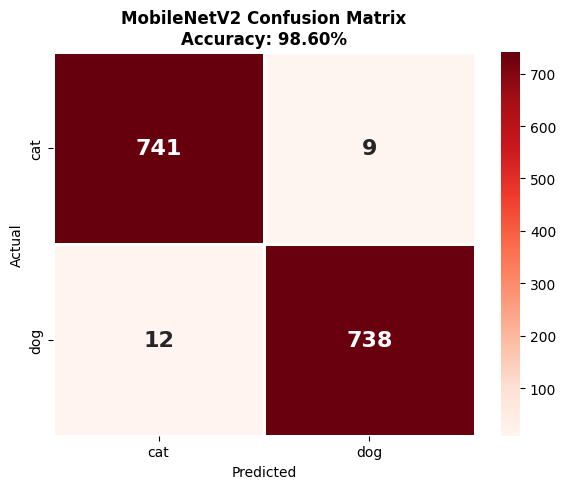

Saved: mobilenet_confusion_matrix.png


In [23]:
# MobileNetV2 predictions
tl_proba = tl_model.predict(test_ds_mn, verbose=0).flatten()
tl_pred  = (tl_proba > 0.5).astype(int)
tl_true  = np.concatenate([y.numpy() for _,y in test_ds_mn]).astype(int)
tl_acc   = accuracy_score(tl_true, tl_pred)
fpr2, tpr2, _ = roc_curve(tl_true, tl_proba)
tl_auc   = auc(fpr2, tpr2)

print(f'MobileNetV2 Test Accuracy: {tl_acc*100:.2f}%')
print(classification_report(tl_true, tl_pred, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(tl_true, tl_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', linewidths=1,
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'size':16,'weight':'bold'})
plt.title(f'MobileNetV2 Confusion Matrix\nAccuracy: {tl_acc*100:.2f}%', fontweight='bold')
plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('mobilenet_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mobilenet_confusion_matrix.png')

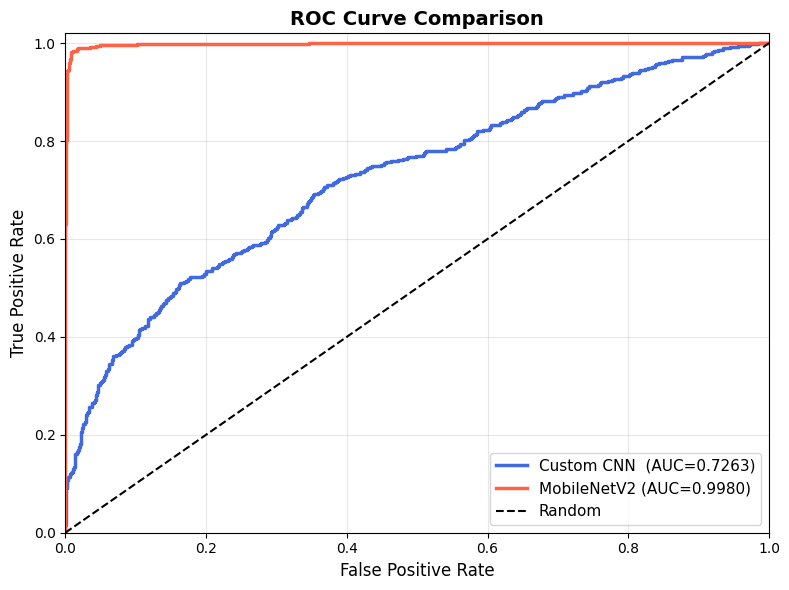

Saved: roc_curve.png


In [24]:
# ROC Curve — both models
plt.figure(figsize=(8,6))
plt.plot(cnn_fpr, cnn_tpr, color='royalblue', lw=2.5,
         label=f'Custom CNN  (AUC={cnn_auc:.4f})')
plt.plot(fpr2,    tpr2,    color='tomato',    lw=2.5,
         label=f'MobileNetV2 (AUC={tl_auc:.4f})')
plt.plot([0,1],[0,1],'k--',lw=1.5,label='Random')
plt.xlim([0,1]); plt.ylim([0,1.02])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate',  fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: roc_curve.png')

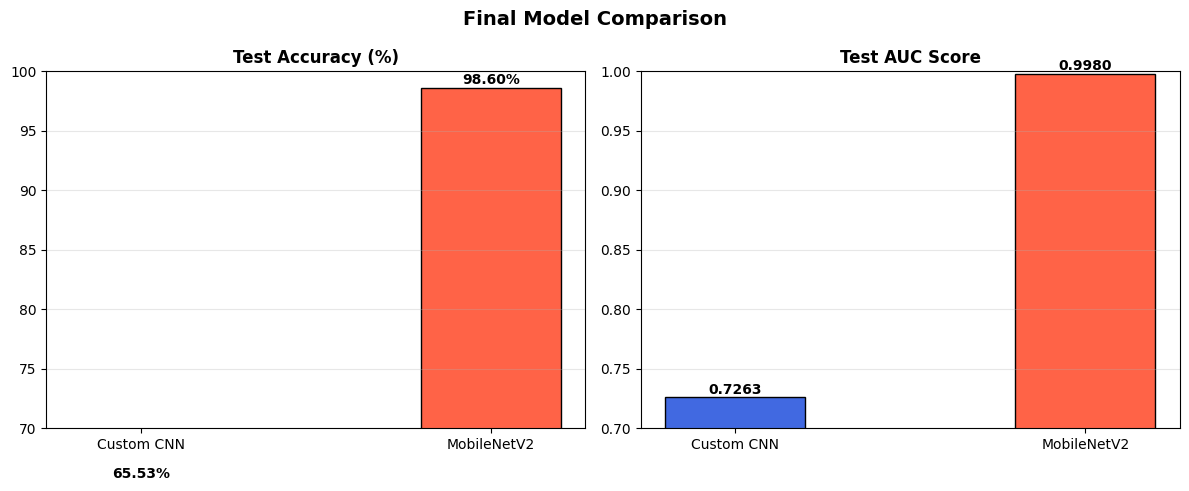


===== FINAL RESULTS =====
Custom CNN  — Accuracy: 65.53%  AUC: 0.7263
MobileNetV2 — Accuracy: 98.60%  AUC: 0.9980
Saved: model_comparison.png


In [25]:
# Final comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Final Model Comparison', fontsize=14, fontweight='bold')
model_names = ['Custom CNN', 'MobileNetV2']
colors = ['royalblue', 'tomato']

accs = [cnn_acc*100, tl_acc*100]
bars = axes[0].bar(model_names, accs, color=colors, edgecolor='black', width=0.4)
axes[0].set_title('Test Accuracy (%)', fontweight='bold')
axes[0].set_ylim([70, 100]); axes[0].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.3, f'{v:.2f}%',
                 ha='center', fontweight='bold')

aucs = [cnn_auc, tl_auc]
bars = axes[1].bar(model_names, aucs, color=colors, edgecolor='black', width=0.4)
axes[1].set_title('Test AUC Score', fontweight='bold')
axes[1].set_ylim([0.7, 1.0]); axes[1].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, aucs):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.4f}',
                 ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n===== FINAL RESULTS =====')
print(f'Custom CNN  — Accuracy: {cnn_acc*100:.2f}%  AUC: {cnn_auc:.4f}')
print(f'MobileNetV2 — Accuracy: {tl_acc*100:.2f}%  AUC: {tl_auc:.4f}')
print('Saved: model_comparison.png')

## Step 10 — Predict on Any Image

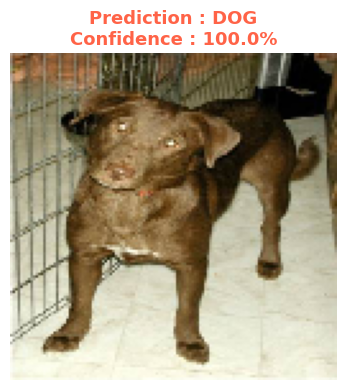

Result: DOG (100.0% confident)
predict_single() ready!
Usage: predict_single("path/to/any/image.jpg")


In [29]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

def predict_single(image_path):
    """
    Predict any image using the best model (MobileNetV2)
    Usage: predict_single('dogs-vs-cats/cat/cat.1.jpg')
    """
    img = tf.keras.utils.load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    arr = tf.keras.utils.img_to_array(img)
    inp = preprocess_input(np.expand_dims(arr, 0))
    prob       = tl_model.predict(inp, verbose=0)[0][0]
    pred_label = CLASS_NAMES[int(prob > 0.5)]
    confidence = prob if prob > 0.5 else 1 - prob
    color      = 'tomato' if pred_label == 'dog' else 'royalblue'
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f'Prediction : {pred_label.upper()}\nConfidence : {confidence*100:.1f}%',
              fontsize=13, fontweight='bold', color=color)
    plt.axis('off'); plt.tight_layout(); plt.show()
    print(f'Result: {pred_label.upper()} ({confidence*100:.1f}% confident)')
    return pred_label, confidence

# ── Test it ───────────────────────────────────────────────────
# predict_single('dogs-vs-cats/cat/cat.1.jpg')
predict_single('dogs-vs-cats/dog/dog.1.jpg')
print('predict_single() ready!')
print('Usage: predict_single("path/to/any/image.jpg")')

---
## ✅ Project Summary

| Item | Detail |
|---|---|
| **Task** | Binary Image Classification — Cat vs Dog |
| **Dataset** | Local: 5,000 cats + 5,000 dogs = 10,000 total |
| **Split** | 70% Train / 15% Val / 15% Test |
| **IMG_SIZE** | 128×128 (optimized for 8GB RAM) |
| **Model 1** | Custom CNN (3 Conv Blocks) |
| **Model 2** | MobileNetV2 Transfer Learning + Fine-Tuning |
| **Expected Accuracy** | CNN ~85-90% | MobileNetV2 ~93-96% |
| **Portfolio Files** | confusion matrices, ROC curve, training history, predictions |
---
*Built with TensorFlow 2.x | Python 3.12 | Jupyter Notebook | Optimized for 8GB RAM*